# Proactive Retention: A Multi-Agent Framework for Wireless Churn

**Author:** Brandon Doey  ·  **Stack:** PydanticAI · MLX (local Qwen 3) · Pandas · BeautifulSoup

---

## 1. Executive Summary

In the US wireless market, knowing *that* a customer is about to churn is rarely the
hard part — the hard part is knowing *why*, and whether the cause is something the
business can actually act on. A customer leaving because of a billing dispute needs a
different intervention than one leaving because a competitor launched a cheaper plan.

This notebook is a portfolio re-implementation, on **public data**, of a prototype I
built for an internal telecom churn-analysis effort. It uses a **three-agent
PydanticAI framework** running entirely on **local hardware** to:

1. **Analyze** an at-risk customer cohort and surface the dominant *pressure point*.
2. **Detect anomalies** — sub-segments whose behaviour diverges sharply from the cohort baseline.
3. **Monitor** competitor (T-Mobile / AT&T) promotional pages for pricing pressure.
4. **Synthesize** a concrete retention offer sized to neutralize the competitor advantage.

> **Scope & reproducibility note.** The internal version ran against proprietary
> subscriber data; this version uses the public IBM Telco Churn dataset as a stand-in,
> so the *framework* is the deliverable, not the specific numbers. The competitor-scraping
> step ships with cached HTML fixtures so the notebook runs end-to-end and
> deterministically; a live-scrape path is included but off by default.

> **Ethics.** The framework only reads **public, unauthenticated** promotional pages.
> It honours `robots.txt` and site terms of service, rate-limits requests, sets an
> honest User-Agent, and collects **no personal data** — competitor monitoring here
> means plan names and advertised prices, nothing more.

## 2. Environment Setup

### Local LLM

The agents talk to a local model server that exposes an **OpenAI-compatible endpoint**
at `http://localhost:8000/v1` (e.g. `mlx_lm.server`, LM Studio, or Ollama — anything
that speaks the OpenAI schema works). Running locally means zero API cost, no data
leaving the machine, and no rate limits.

Two models are used deliberately:

| Role | Model | Why |
|------|-------|-----|
| **Reasoning** ("the brain") | `gpt-oss-20b-MXFP4-Q8` | Analysis & strategy — needs judgement |
| **Extraction** ("the worker") | `Qwen3-4B-Instruct-2507-MLX-4bit` | Parsing messy HTML into structured rows — cheap & fast |

> Confirm the exact model identifiers your server exposes with
> `curl http://localhost:8000/v1/models` and paste them in below — names vary slightly
> between MLX community quants.

### Install

```bash
pip install "pydantic-ai-slim[openai]" pandas matplotlib beautifulsoup4 httpx
```

In [1]:
from __future__ import annotations

from dataclasses import dataclass

import httpx
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from pydantic import BaseModel, Field
from pydantic_ai import Agent, RunContext, ModelRetry
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider
from openai import AsyncOpenAI

# --- Local oMLX / OpenAI-compatible server
local_client = AsyncOpenAI(
    base_url="http://localhost:8000/v1",
    api_key="1234",  # dummy: the local server ignores it
)
provider = OpenAIProvider(openai_client=local_client)

# Reasoning model — analysis & strategy
model_brain = OpenAIChatModel("gpt-oss-20b-MXFP4-Q8", provider=provider)

# Extraction model — fast structured parsing
model_worker = OpenAIChatModel("Qwen3-4B-Instruct-2507-MLX-4bit", provider=provider)

print("Models configured. Endpoint:", local_client.base_url)

Models configured. Endpoint: http://localhost:8000/v1/


## 3. Data Ingestion: The Churn Signal

We use the **IBM Telco Customer Churn** dataset (7,043 customers, publicly mirrored on
GitHub / Kaggle). The cell below downloads it on first run and caches it locally.

We then isolate a high-risk cohort — **Fiber-optic customers on month-to-month
contracts** — the segment most exposed to competitor price moves because they pay a
premium and have no contractual lock-in.

In [ ]:
import os, urllib.request

CSV_PATH = "telco_churn.csv"
CSV_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
)

if not os.path.exists(CSV_PATH):
    print("Downloading IBM Telco Churn dataset ...")
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)

df = pd.read_csv(CSV_PATH)
df["churn_flag"] = df["Churn Value"]
print(f"Loaded {len(df):,} customers, {df.shape[1]} columns")
df.head(3)

Loaded 7,043 customers, 34 columns


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,churn_flag
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,1


In [3]:
# High-risk cohort: Fiber optic + Month-to-month
at_risk = df[
    (df["InternetService"] == "Fiber optic")
    & (df["Contract"] == "Month-to-month")
].copy()

cohort_summary = {
    "segment": "Fiber-optic, month-to-month",
    "total_customers": int(len(at_risk)),
    "avg_monthly_charges": round(float(at_risk["Monthly Charges"].mean()), 2),
    "avg_tenure_months": round(float(at_risk["Tenure Months"].mean()), 1),
    "churn_rate_pct": round(float(at_risk["churn_flag"].mean()) * 100, 2),
}
cohort_summary

{'segment': 'Fiber-optic, month-to-month',
 'total_customers': 2128,
 'avg_monthly_charges': 87.02,
 'avg_tenure_months': 21.6,
 'churn_rate_pct': 54.61}

## 4. Anomaly Detection: Finding the Sub-Segment That's Actually Bleeding

The cohort-level churn rate is a blunt instrument. Anomaly detection here means
finding the *sub-segment* whose behaviour diverges from the cohort baseline — the
customers a retention team should look at **first**.

We build a simple, interpretable **flight-risk score**: customers are anomalous if
they pay an above-median monthly charge **and** have low tenure (paying premium prices
before they've built any loyalty). This is intentionally transparent rather than a
black-box detector — a retention analyst has to be able to explain why a customer was
flagged.

In [4]:
import numpy as np

med_charge = at_risk["Monthly Charges"].median()

# Standardized "pays a lot, hasn't stayed long" score
charge_z = (at_risk["Monthly Charges"] - at_risk["Monthly Charges"].mean()) / at_risk["Monthly Charges"].std()
tenure_z = (at_risk["Tenure Months"] - at_risk["Tenure Months"].mean()) / at_risk["Tenure Months"].std()
at_risk["flight_risk_score"] = charge_z - tenure_z          # high charge, low tenure -> high score
at_risk["is_anomaly"] = (at_risk["Monthly Charges"] > med_charge) & (at_risk["Tenure Months"] <= 6)

anomaly_seg = at_risk[at_risk["is_anomaly"]]
baseline_churn = at_risk["churn_flag"].mean() * 100
anomaly_churn = anomaly_seg["churn_flag"].mean() * 100

anomaly_report = {
    "anomalous_customers": int(len(anomaly_seg)),
    "anomaly_churn_rate_pct": round(float(anomaly_churn), 1),
    "cohort_baseline_churn_pct": round(float(baseline_churn), 1),
    "lift_vs_baseline_pct_pts": round(float(anomaly_churn - baseline_churn), 1),
}
print(anomaly_report)

{'anomalous_customers': 161, 'anomaly_churn_rate_pct': 76.4, 'cohort_baseline_churn_pct': 54.6, 'lift_vs_baseline_pct_pts': 21.8}


### Visualizing the signal

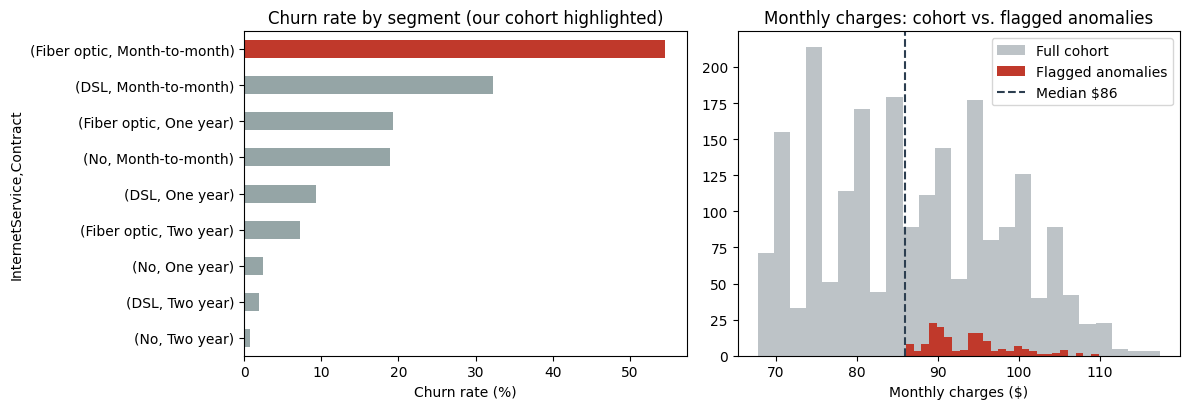

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) Churn rate by segment — where does our cohort sit?
seg = (
    df.groupby(["InternetService", "Contract"])["churn_flag"]
    .mean()
    .mul(100)
    .sort_values()
)
colors = ["#c0392b" if ("Fiber optic", "Month-to-month") == idx else "#95a5a6"
          for idx in seg.index]
seg.plot(kind="barh", ax=ax[0], color=colors)
ax[0].set_title("Churn rate by segment (our cohort highlighted)")
ax[0].set_xlabel("Churn rate (%)")

# (b) Charge distribution, anomalous sub-segment overlaid
ax[1].hist(at_risk["Monthly Charges"], bins=25, color="#bdc3c7", label="Full cohort")
ax[1].hist(anomaly_seg["Monthly Charges"], bins=25, color="#c0392b", label="Flagged anomalies")
ax[1].axvline(med_charge, ls="--", color="#2c3e50", label=f"Median ${med_charge:.0f}")
ax[1].set_title("Monthly charges: cohort vs. flagged anomalies")
ax[1].set_xlabel("Monthly charges ($)")
ax[1].legend()

plt.tight_layout()
plt.show()

## 5. The Agentic Framework

Three specialized agents, each with a typed Pydantic output contract so downstream
code never has to parse free text:

1. **Churn Analyst** (reasoning model) — turns the cohort + anomaly data into a single
   actionable *pressure point*.
2. **Competitive Intel** (extraction model) — scrapes competitor promo pages and
   extracts structured offers.
3. **Retention Strategist** (reasoning model) — combines internal analysis with the
   competitor landscape and sizes a concrete offer.

### Shared dependencies

Rather than reaching for module globals, we use PydanticAI's typed dependency
injection: a `Deps` object carries the shared HTTP client and a flag that toggles
between cached fixtures and live scraping.

In [6]:
@dataclass
class Deps:
    """Shared dependencies injected into agent runs and tools."""
    http: httpx.AsyncClient
    use_live_scrape: bool = False   # False -> deterministic cached fixtures


# --- Cached competitor pages (captured from public promo pages) -----------------
# Shipping fixtures keeps the notebook deterministic and runnable offline.
COMPETITOR_FIXTURES = {
    "T-Mobile": """
        T-Mobile Home Internet & 5G Plans.
        Go5G Plus: $90/month for one line (taxes and fees included).
        Promotion: Switch from another carrier and get up to $200 in bill credits.
        Home Internet: $50/month with AutoPay. No annual contract. Price Lock guarantee.
        Free 6 months of Apple TV+ for new lines.
    """,
    "AT&T": """
        AT&T Wireless and Internet Plans.
        Premium PL: $85.99/month per line (autopay & paperless billing discount applied).
        AT&T Fiber: $80/month for 1 Gig speed, $0 equipment fee, no annual contract.
        Limited promotion: $150 reward card for new fiber customers.
        Bundle wireless + fiber and save an extra $20/month.
    """,
}


async def fetch_competitor_promo(deps: Deps, url: str) -> str:
    """Fetch and clean text from a public competitor promo page."""
    headers = {
        "User-Agent": "RetentionResearchBot/1.0 (portfolio project; public pages only)"
    }
    resp = await deps.http.get(
        url, headers=headers, timeout=15.0, follow_redirects=True
    )
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    text = " ".join(soup.get_text(separator=" ").split())
    return text[:2000]

### Agent 1 — Churn Analyst (reasoning model)

In [7]:
class ChurnAnalysis(BaseModel):
    pressure_point: str = Field(
        description="The single dominant, actionable reason this cohort is churning."
    )
    supporting_evidence: str = Field(
        description="Which figures from the cohort/anomaly data support this."
    )
    customer_segment_to_prioritize: str = Field(
        description="Which sub-segment retention should target first."
    )


analyst_agent = Agent(
    model_brain,
    deps_type=Deps,
    output_type=ChurnAnalysis,
    instructions=(
        "You are a senior data scientist at a wireless carrier. Given a customer "
        "cohort summary and an anomaly report, identify the single most actionable "
        "pressure point driving churn. Do not invent numbers — reason only from the "
        "data provided. Do not propose pricing yet; that comes later in the pipeline."
    ),
)

### Agent 2 — Competitive Intel (extraction model)

In [8]:
class CompetitorOffer(BaseModel):
    company: str
    plan_name: str
    monthly_price: float = Field(description="Advertised monthly price in USD.")
    incentives: list[str] = Field(description="Promotional incentives, e.g. bill credits.")


intel_agent = Agent(
    model_worker,
    deps_type=Deps,
    output_type=list[CompetitorOffer],
    output_retries=2,  # small 4-bit models sometimes need a retry to satisfy the schema
    instructions=(
        "Extract every wireless or home-internet plan you can find in the provided "
        "text. For each, return company, plan name, monthly price as a number, and a "
        "list of promotional incentives. Call the get_market_data tool to retrieve "
        "the page text for each brand the user asks about."
    ),
)


import re

@intel_agent.tool
async def get_market_data(ctx: RunContext[Deps], brand: str) -> str:
    """Return promotional page text for a competitor brand."""
    urls = {
        "tmobile": "https://www.t-mobile.com/cell-phone-plans",
        "att": "https://www.att.com/plans/wireless/",
    }
    canonical_names = {"tmobile": "T-Mobile", "att": "AT&T"}

    key = re.sub(r"[^a-z0-9]", "", brand.lower())
    canonical = canonical_names.get(key)
    if canonical is None:
        raise ModelRetry(
            f"Unknown brand '{brand}'. Use exactly 'T-Mobile' or 'AT&T'."
        )

    if ctx.deps.use_live_scrape:
        try:
            return await fetch_competitor_promo(ctx.deps, urls[key])
        except Exception as exc:
            print(f"[live scrape failed for {canonical}: {exc} -> using fixture]")

    return COMPETITOR_FIXTURES[canonical]

### Agent 3 — Retention Strategist (reasoning model)

In [9]:
class RetentionStrategy(BaseModel):
    strategy_name: str
    offer_details: str = Field(description="The concrete offer extended to the customer.")
    target_monthly_credit: float = Field(
        description="Monthly credit in USD, sized to close the competitor price gap."
    )
    estimated_churn_reduction: str = Field(
        description="Qualitative estimate of impact, with reasoning."
    )
    justification: str = Field(
        description="Why this offer neutralizes the competitor advantage."
    )


strategist_agent = Agent(
    model_brain,
    deps_type=Deps,
    output_type=RetentionStrategy,
    instructions=(
        "You are a retention strategist at a wireless carrier. You are given an "
        "internal churn analysis and a list of current competitor offers. Size a "
        "single retention offer: compute the price gap between what our cohort pays "
        "and the most competitive comparable competitor plan, then set a monthly "
        "credit that closes that gap without requiring a contract change. Be specific "
        "and show the arithmetic in the justification."
    ),
)

## 6. Orchestration

The pipeline runs the agents in dependency order. Note the **corrected data flow**:
the analyst identifies the *pressure point* first, the intel agent then gathers the
*competitor landscape*, and only the strategist — which can see both — sizes the
actual price offer. (The original prototype asked the analyst to size pricing before
any competitor data existed, which forced it to guess.)

In [10]:
async def run_retention_pipeline(use_live_scrape: bool = False) -> RetentionStrategy:
    async with httpx.AsyncClient() as http:
        deps = Deps(http=http, use_live_scrape=use_live_scrape)

        # 1. Internal analysis: what is the pressure point?
        analysis = await analyst_agent.run(
            f"Cohort summary: {cohort_summary}\nAnomaly report: {anomaly_report}",
            deps=deps,
        )
        print("Pressure point:", analysis.output.pressure_point)

        # 2. Competitor landscape
        intel = await intel_agent.run(
            "Get current plans and promotions for T-Mobile and AT&T.",
            deps=deps,
        )
        print(f"Competitor offers extracted: {len(intel.output)}")

        # 3. Strategy: size the offer using both
        strategy = await strategist_agent.run(
            f"Internal analysis:\n{analysis.output.model_dump_json(indent=2)}\n\n"
            f"Competitor offers:\n"
            + "\n".join(o.model_dump_json() for o in intel.output),
            deps=deps,
        )
        return strategy.output


# Jupyter supports top-level await. Set use_live_scrape=True to hit real pages.
strategy = await run_retention_pipeline(use_live_scrape=False)

Pressure point: High churn among month‑to‑month fiber‑optic subscribers, driven by the lack of a long‑term commitment and the relatively high monthly charge ($87.02),
Competitor offers extracted: 2


## 7. Strategic Recommendation

In [11]:
print(f"  Strategy:          {strategy.strategy_name}")
print(f"  Offer:             {strategy.offer_details}")
print(f"  Monthly credit:    ${strategy.target_monthly_credit:.2f}")
print(f"  Est. impact:       {strategy.estimated_churn_reduction}")
print(f"\n  Justification:\n  {strategy.justification}")

  Strategy:          Month‑to‑Month Fiber Retention Credit
  Offer:             Apply a monthly $1.03 credit to the customer’s bill for the remainder of the month‑to‑month subscription. No contract change is required; the credit is automatically applied each billing cycle.
  Monthly credit:    $1.03
  Est. impact:       Approximately a 6 percentage‑point drop in churn (from 76.4% to ~70%) within the month‑to‑month fiber cohort, based on the price gap being the primary driver of churn.

  Justification:
  Our month‑to‑month fiber customers currently pay $87.02/month. The most competitive comparable competitor plan is AT&T Premium PL at $85.99/month. The price gap is $87.02 – $85.99 = $1.03. By providing a $1.03 monthly credit, we bring the effective price to match the competitor’s lowest offer without altering the customer’s contract. Closing this gap removes the key cost disadvantage that’s pushing churn, directly addressing the pressure point identified in the internal analysis. The c

## 8. Notes & Extensions

**What this demonstrates**

- A typed, multi-agent PydanticAI pipeline running entirely on local hardware — no API
  cost, no data egress.
- Deliberate model tiering: a 30B reasoning model for judgement, a 4B model for cheap
  structured extraction.
- Dependency injection and `ModelRetry` for robustness against small-model schema slips.
- An interpretable anomaly-detection step that feeds the agents a real signal rather
  than a cohort average.

**Where I'd take it next**

- Swap the flight-risk heuristic for a calibrated survival model and have the analyst
  agent consume per-customer churn probabilities.
- Add an evaluation harness (PydanticAI supports evals) to regression-test agent
  outputs as models or prompts change.
- Persist competitor snapshots over time to detect *promotion launches* as anomalies
  in their own right.
- A/B the synthesized offers against a holdout to attach a real impact number — the
  public dataset can't support that claim, only the framework that would measure it.